In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


# Data Loading

In [2]:
train_df=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

In [3]:
train_df.sample(7)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
235070,235070,Female,0,Yes,No,61,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.10,1462.85,No
543802,543802,Male,0,Yes,Yes,23,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.30,475.20,No
221516,221516,Female,0,No,No,37,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),100.85,3541.80,No
138329,138329,Male,0,Yes,Yes,55,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Mailed check,86.10,4860.85,No
11974,11974,Female,0,Yes,Yes,62,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),89.20,6449.15,No
203402,203402,Female,1,Yes,No,33,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.20,3414.25,Yes
591875,591875,Male,0,No,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.80,834.80,No


In [4]:
test_df.sample(7)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
43701,637895,Male,0,Yes,Yes,59,Yes,Yes,DSL,Yes,No,No,No,Yes,Yes,Two year,Yes,Electronic check,74.75,4189.70
145667,739861,Female,0,Yes,No,57,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,25.00,1505.90
68807,663001,Male,0,No,No,1,Yes,No,DSL,Yes,No,No,Yes,No,No,Month-to-month,Yes,Mailed check,35.55,35.55
106319,700513,Female,0,No,No,17,Yes,No,Fiber optic,No,No,Yes,Yes,Yes,No,Month-to-month,No,Electronic check,88.85,1461.10
231936,826130,Female,0,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.25,94.25
154329,748523,Male,1,Yes,No,53,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,One year,Yes,Electronic check,100.45,5347.95
177622,771816,Female,0,No,No,5,Yes,No,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.45,474.80


In [5]:
print(train_df.shape)
print(test_df.shape)

(594194, 21)
(254655, 20)


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

# EDA

## Univariate Analysis

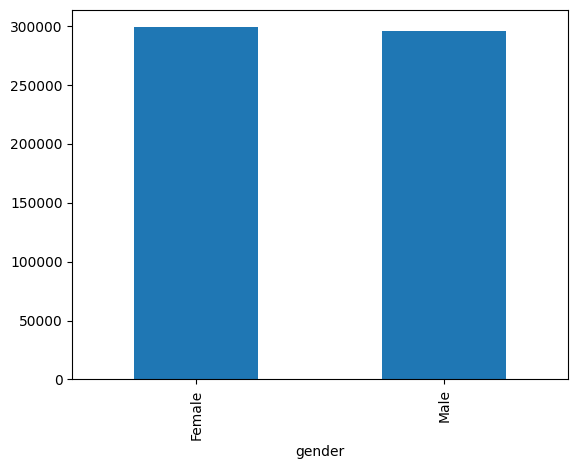

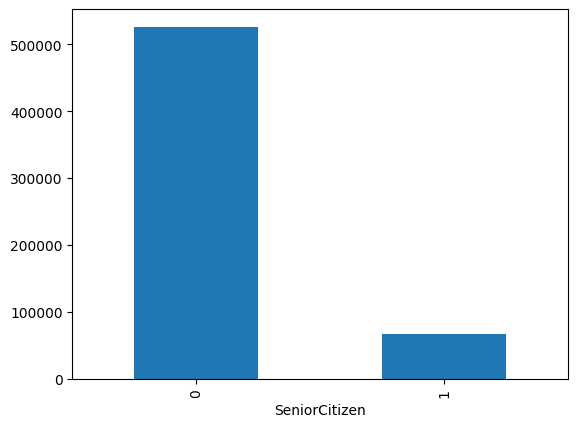

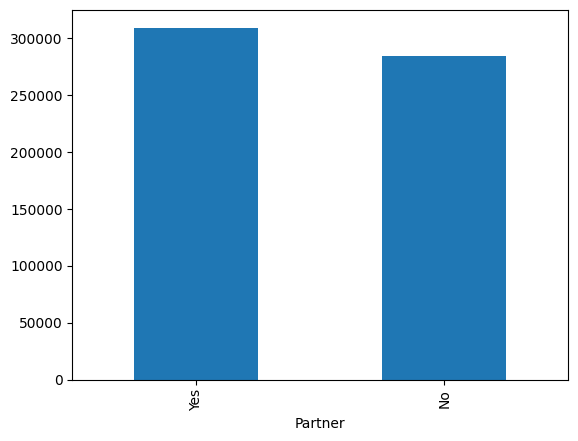

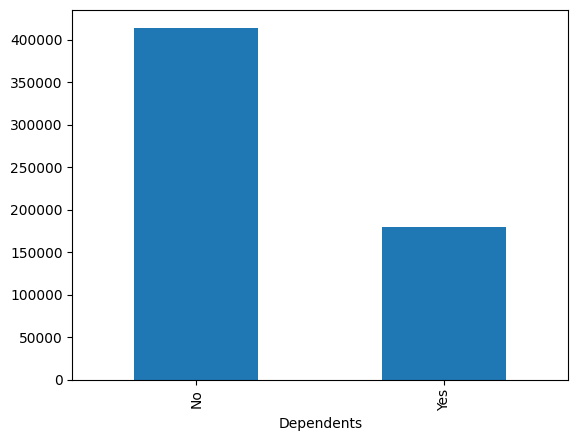

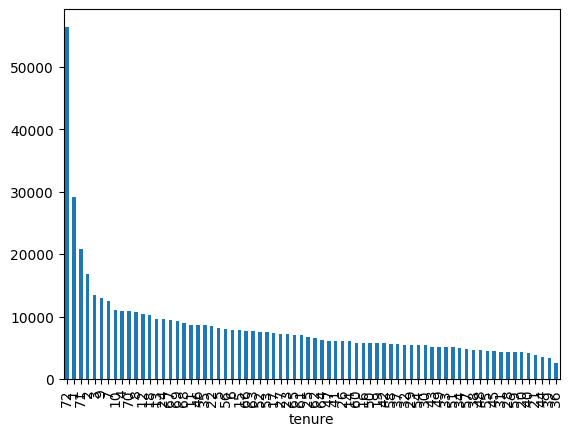

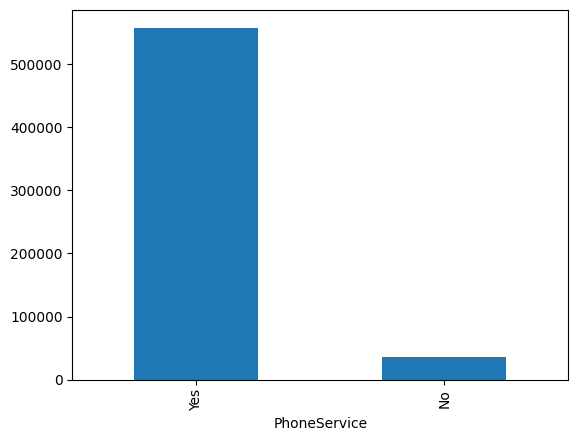

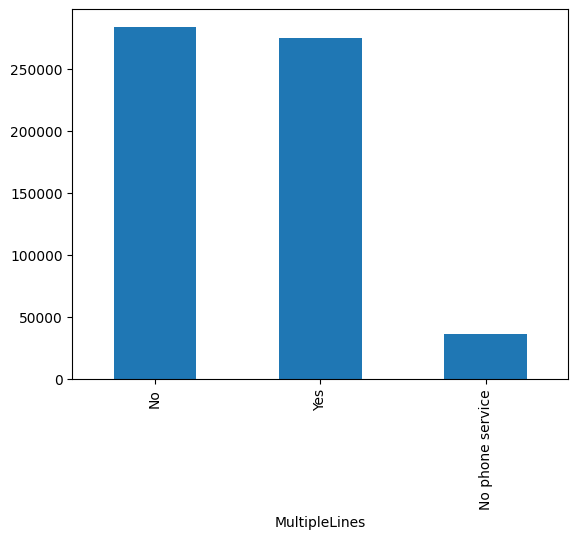

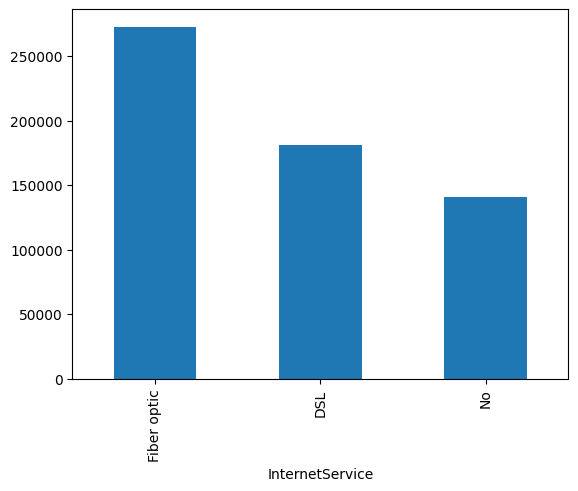

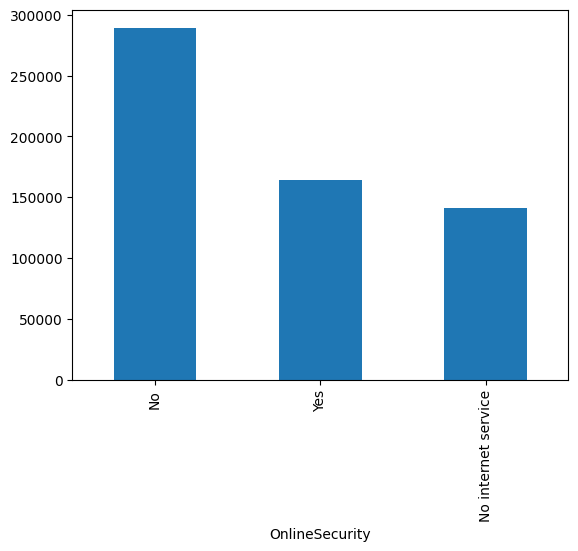

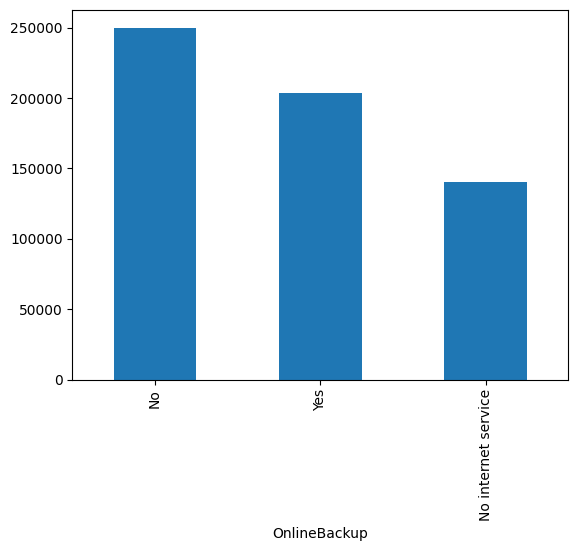

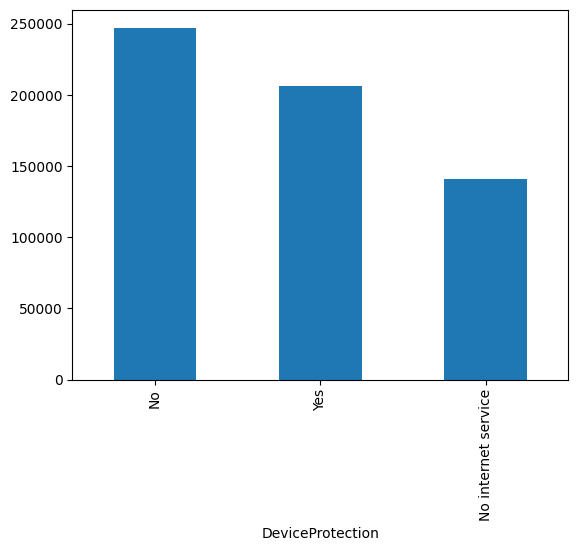

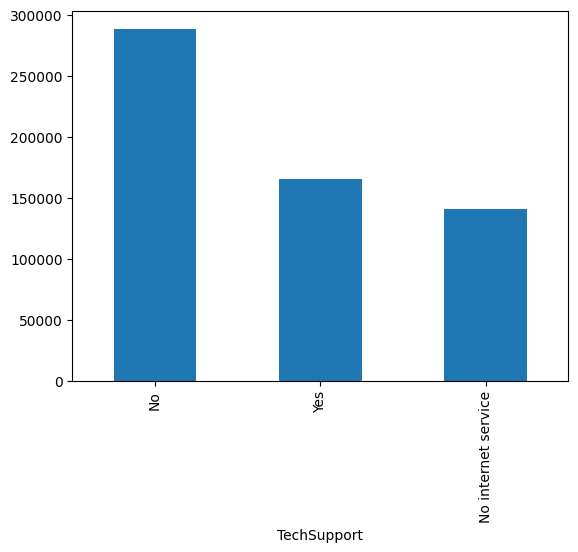

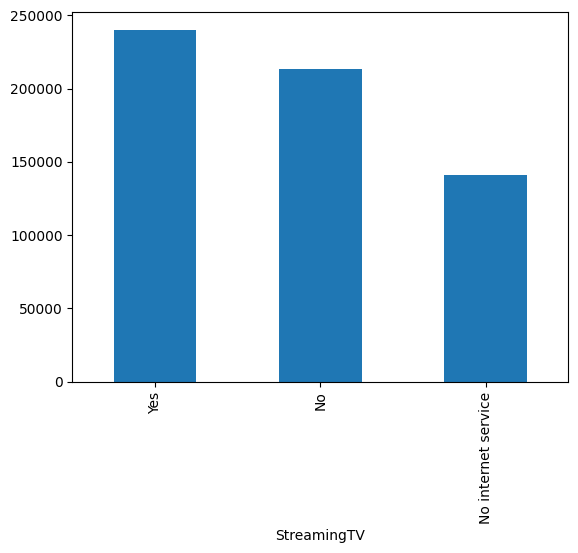

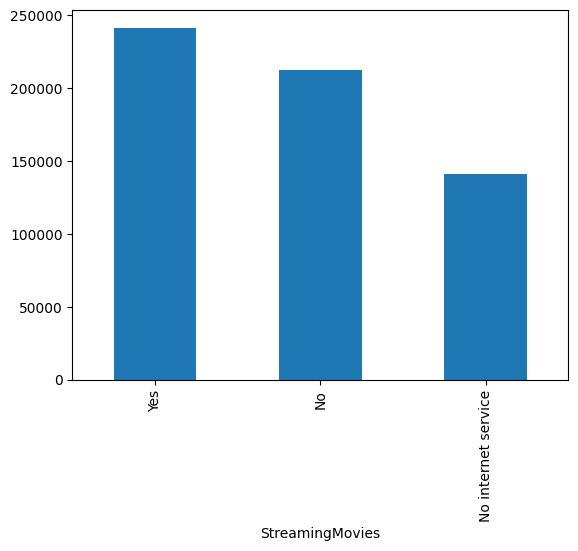

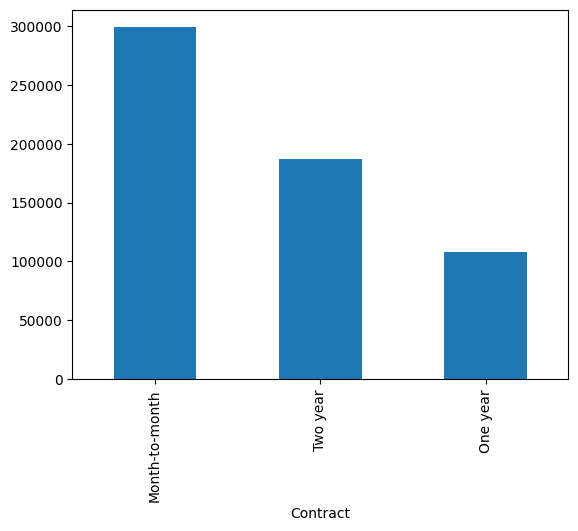

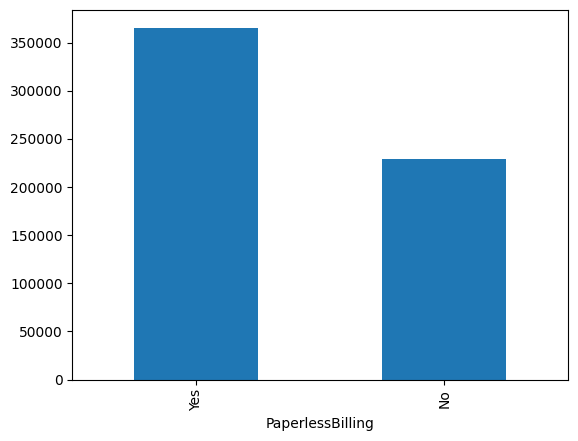

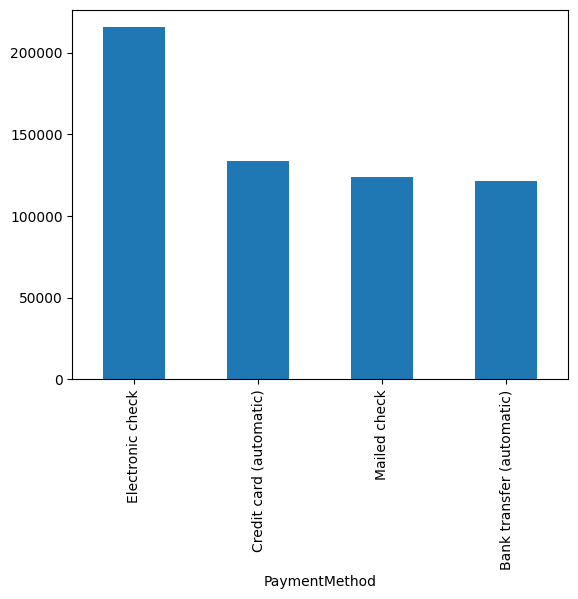

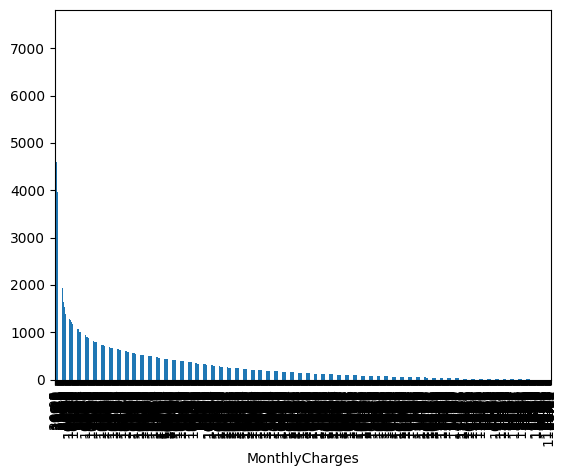

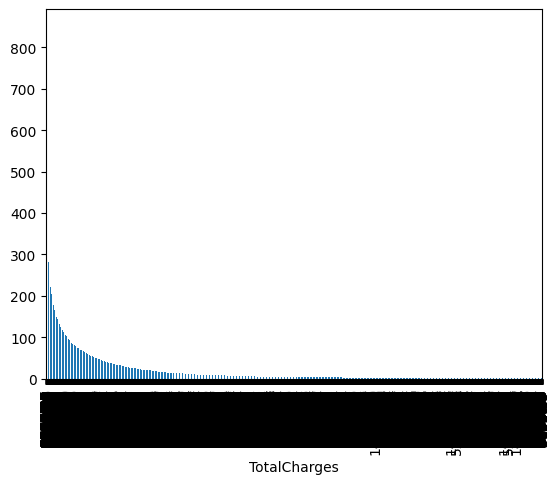

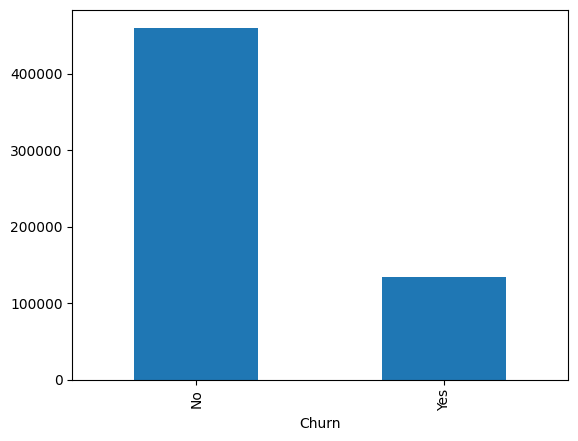

In [7]:
for col in train_df.columns:
    if col == "id":
        continue
    plt.figure()
    if col in ['int64', 'float64']:
        plt.hist(train_df[col])
    else:
        train_df[col].value_counts().plot(kind='bar')
    plt.show()

### Checking if our categories are balanced and also the skewness (using Entropy)

I calculated the entropy for all the categorical text columns to see if the data is balanced or skewed. Basically, a higher entropy means the data is split pretty evenly across the options. A lower entropy means one option is totally dominating the column.

**Perfectly balanced columns (High Entropy for Yes/No):**
* **Gender (0.6931):** It's almost exactly a 50/50 split.
* **Partner (0.6923):** This is also really balanced (52% Yes / 48% No).

**Heavily one-sided columns (Low Entropy):**
* **PhoneService (0.2300):** This one is super skewed. Like 94% of the customers have phone service, so this column probably won't be very helpful for the model.
* **Dependents (0.6131):** Mostly "No" (around 70%).

**Columns with more than two options:**
* **PaymentMethod (1.3547):** This one has four categories and a high entropy score. People are pretty evenly spread out across the different payment types.
* **InternetService, OnlineSecurity, TechSupport, etc. (~1.04 to 1.07):** These have three options and are moderately balanced. This is mostly because there is a solid ~23.6% chunk of people in all these columns who just don't have internet service at all.

**Our Target Variable:**
* **Churn (0.5334):** The target variable is pretty **imbalanced** (~77% No / ~23% Yes). I'll have to keep this in mind and handle it before training the model so it doesn't just guess "No" every time.

In [8]:
from scipy.stats import entropy

for col in train_df.columns:
    if train_df[col].dtype in ['int64', 'float64']:
        print(col)
        print(train_df[col].describe())
        print(f"skew: {train_df[col].skew()} \n")
    else:
        percentages = train_df[col].value_counts(normalize=True) * 100
        print("Percentages:\n", percentages.round(2))
        
        #Entropy (Single number measuring imbalance)
        counts = train_df[col].value_counts()
        ent = entropy(counts)
        print(f"Entropy: {ent:.4f} \n")

id
count    594194.000000
mean     297096.500000
std      171529.177262
min           0.000000
25%      148548.250000
50%      297096.500000
75%      445644.750000
max      594193.000000
Name: id, dtype: float64
skew: -1.4041483035953774e-15 

Percentages:
 gender
Female    50.28
Male      49.72
Name: proportion, dtype: float64
Entropy: 0.6931 

SeniorCitizen
count    594194.000000
mean          0.114102
std           0.317936
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: SeniorCitizen, dtype: float64
skew: 2.4275257022803953 

Percentages:
 Partner
Yes    52.1
No     47.9
Name: proportion, dtype: float64
Entropy: 0.6923 

Percentages:
 Dependents
No     69.74
Yes    30.26
Name: proportion, dtype: float64
Entropy: 0.6131 

tenure
count    594194.000000
mean         36.577258
std          25.061922
min           1.000000
25%          12.000000
50%          35.000000
75%          62.000000
max          72.000000
N

## Bivariate Analysis

<Figure size 640x480 with 0 Axes>

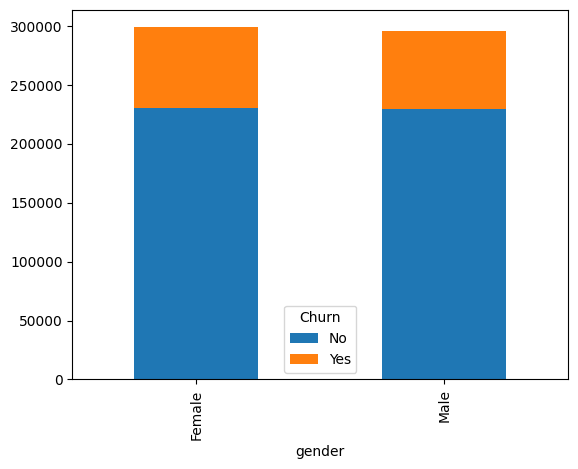

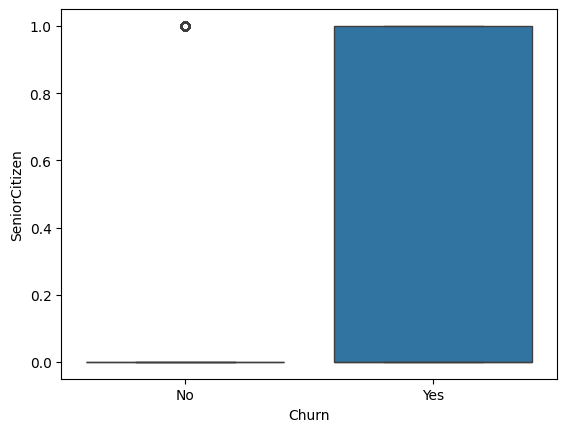

<Figure size 640x480 with 0 Axes>

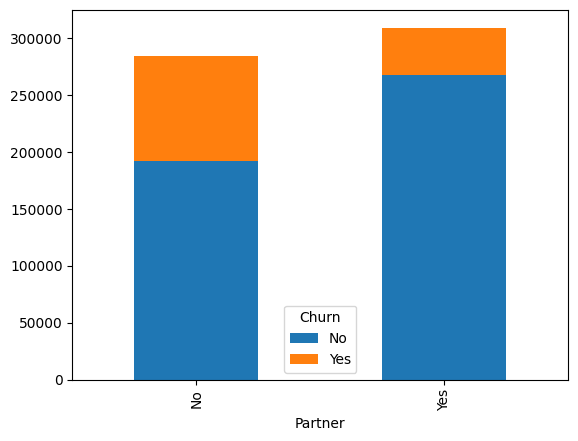

<Figure size 640x480 with 0 Axes>

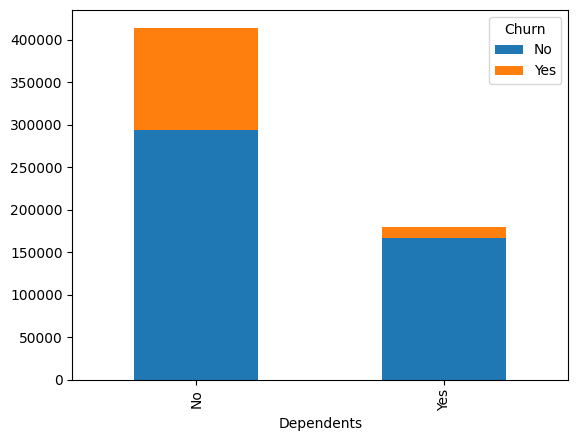

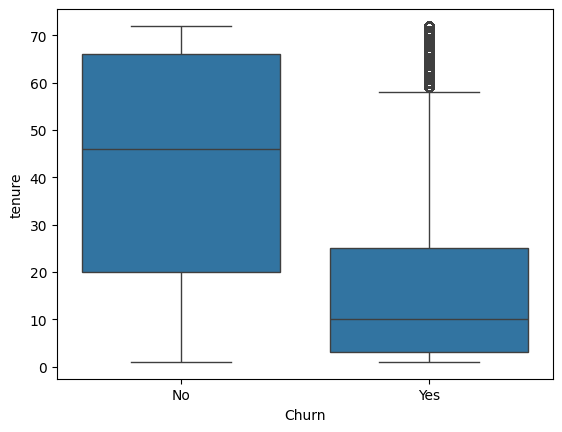

<Figure size 640x480 with 0 Axes>

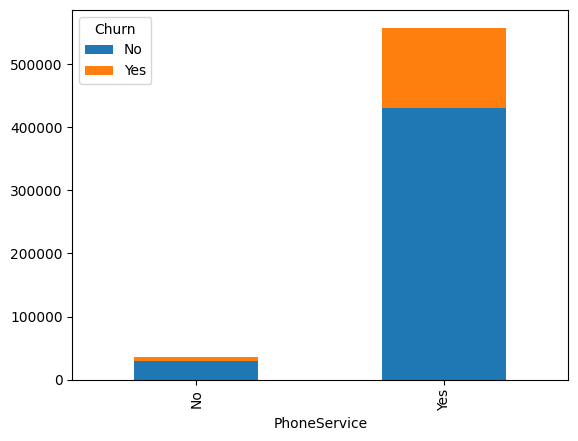

<Figure size 640x480 with 0 Axes>

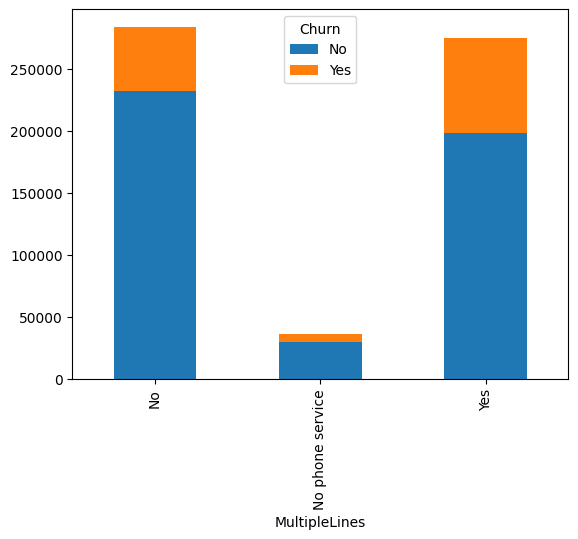

<Figure size 640x480 with 0 Axes>

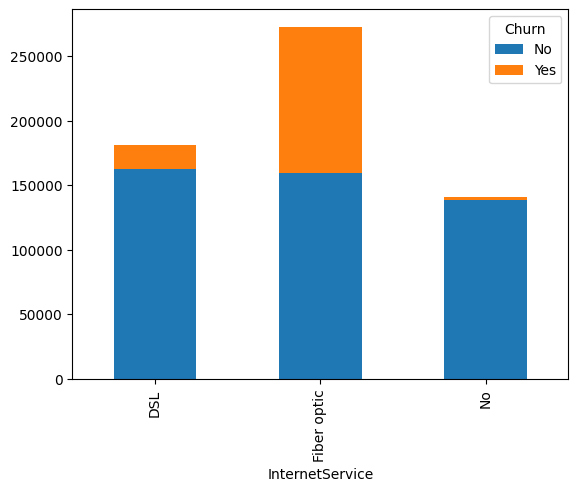

<Figure size 640x480 with 0 Axes>

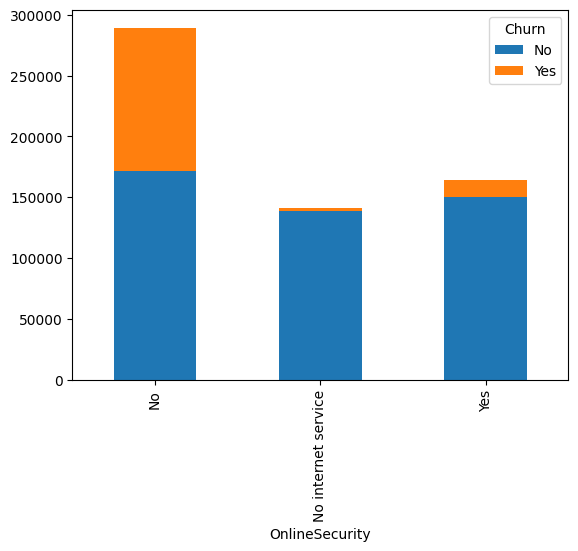

<Figure size 640x480 with 0 Axes>

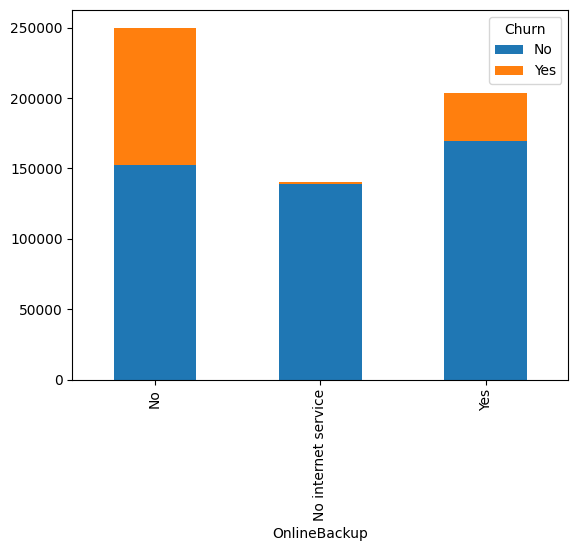

<Figure size 640x480 with 0 Axes>

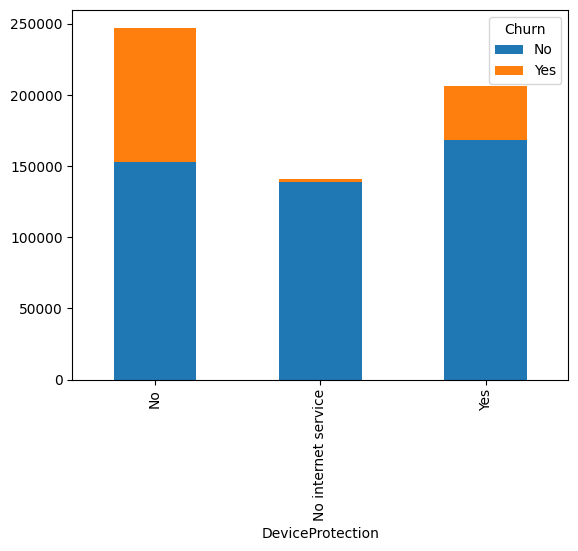

<Figure size 640x480 with 0 Axes>

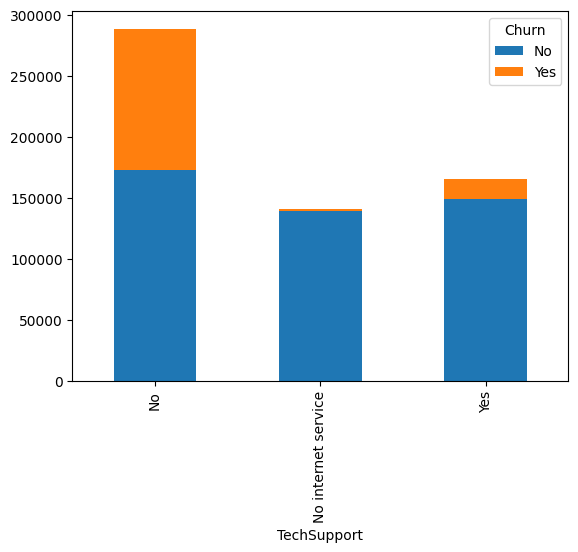

<Figure size 640x480 with 0 Axes>

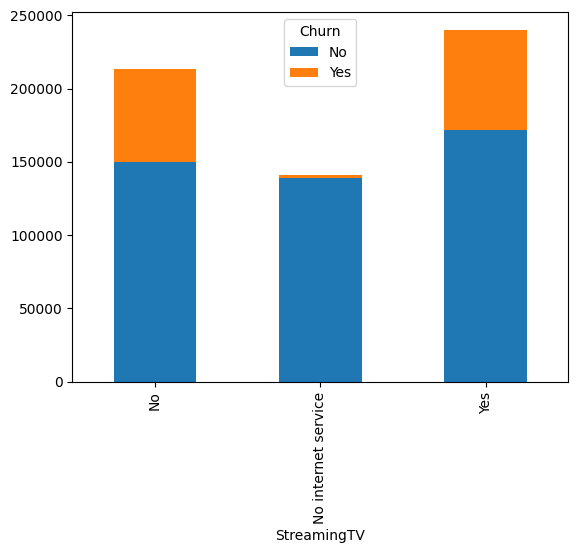

<Figure size 640x480 with 0 Axes>

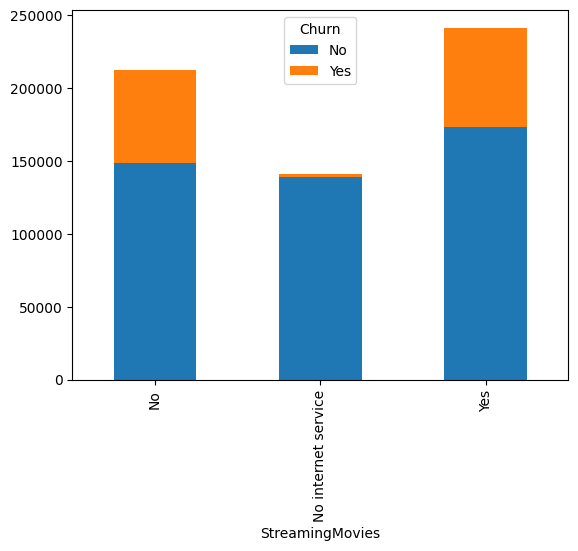

<Figure size 640x480 with 0 Axes>

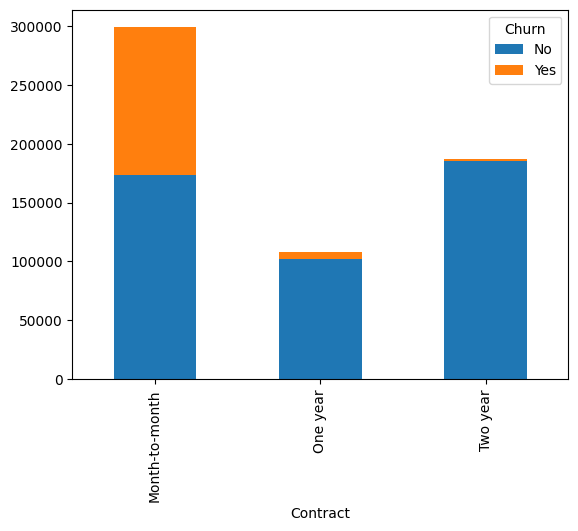

<Figure size 640x480 with 0 Axes>

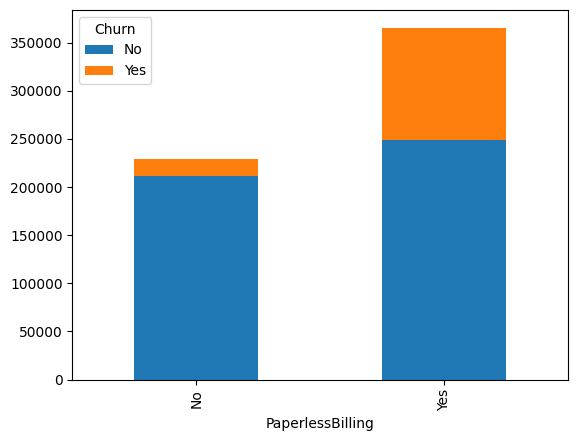

<Figure size 640x480 with 0 Axes>

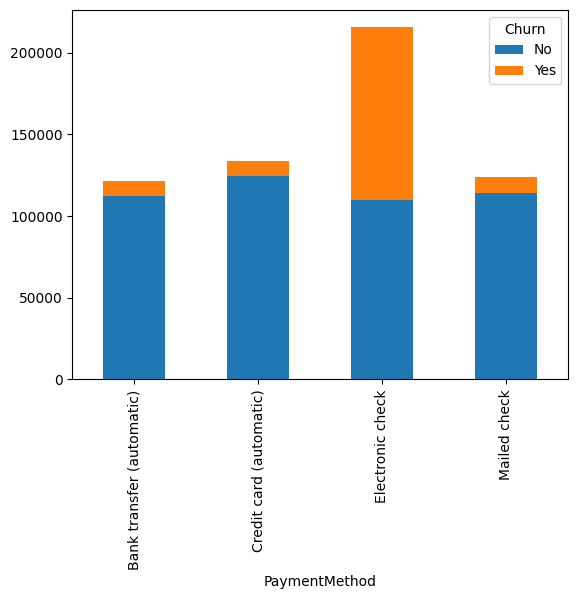

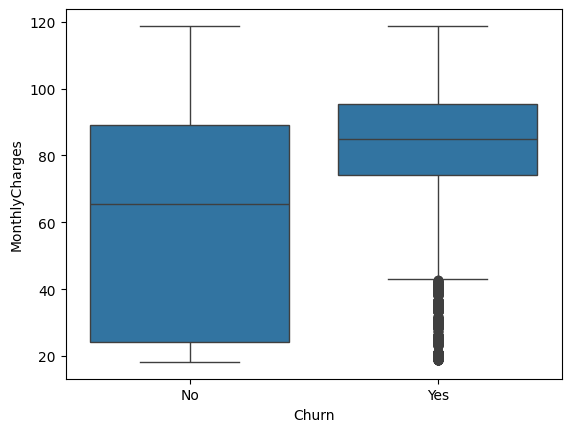

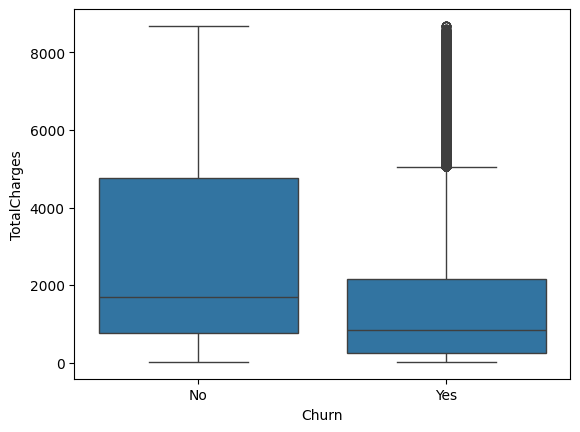

<Figure size 640x480 with 0 Axes>

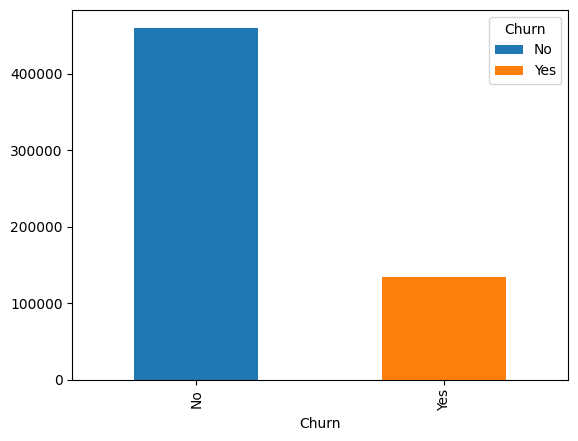

In [9]:
target  = "Churn"
for col in train_df.columns:
    if col == "id":
        continue

    plt.figure()
    if train_df[col].dtype in ["int64", "float64"]:
        sns.boxplot(y=col, x=target, data=train_df)
    else:
        pd.crosstab(train_df[col], train_df[target]).plot(kind='bar', stacked=True)
    plt.show()

## Multivariate Analysis

Here we can see tenure, monthly charges and total charges are correlated. Keeping all three creates multicollinearity and we kinda feed redundant data to the model

Basically,

TotalCharges = MonthlyCharges*Tenure (So we do not actually need TotalCharges)
along with that Features like "*AverateMonthlyCharge*" and "*BillIncrement*" can be created.


**AverageMonthlyCharge** = (TotalCharges/Tenure)


**BillIncrement** = MonthlyCharge>AverageMonthlyCharge

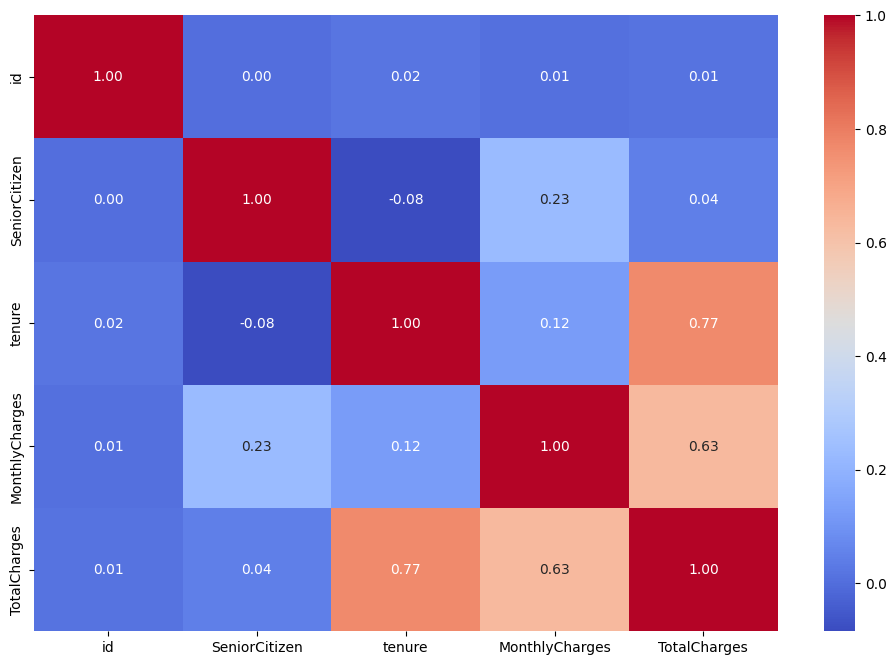

In [10]:
numeric_df = train_df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

Applying Cramer's V to find correlation between categorical features

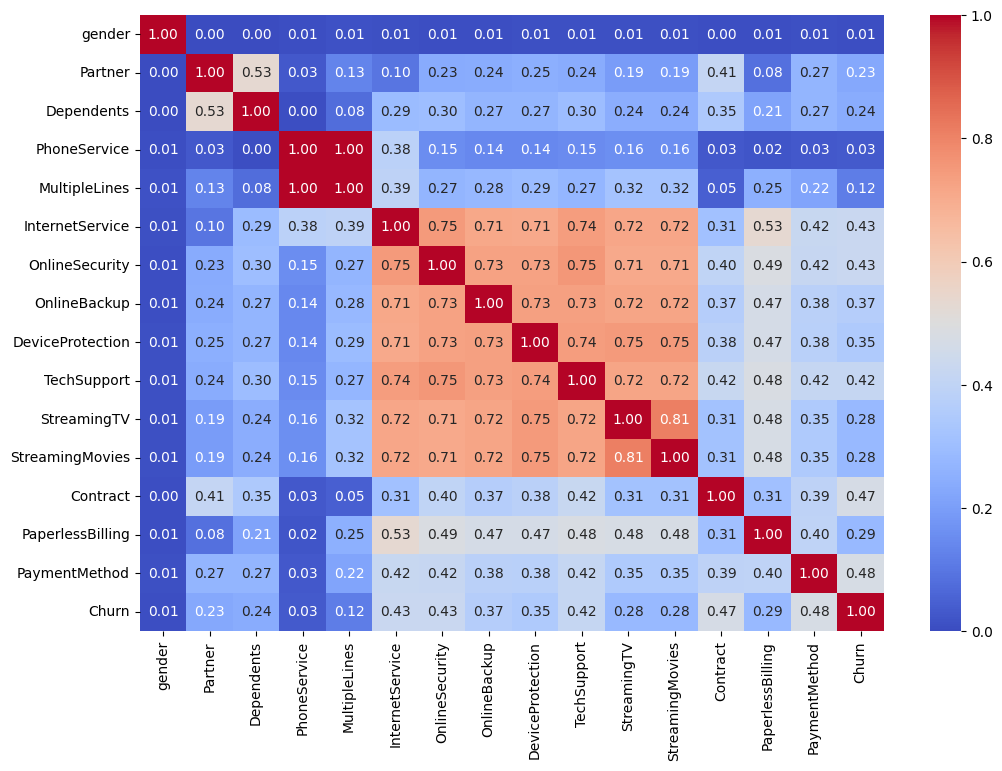

In [11]:
import scipy.stats as ss

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    min_dim = min((kcorr-1), (rcorr-1))
    if min_dim == 0:
        return 0.0
    return np.sqrt(phi2corr / min_dim)

cat_cols = train_df.select_dtypes(include=['object', 'category']).columns
cat_corr_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cat_corr_matrix.loc[col1, col2] = cramers_v(train_df[col1], train_df[col2])

cat_corr_matrix = cat_corr_matrix.astype(float)

plt.figure(figsize=(12, 8))
sns.heatmap(cat_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

# Feature Selection and Engineering

In [12]:
def feature_engineering(df):

    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
    safe_tenure = df['tenure'].replace(0, 1)

    df['AverageCharge'] = df['TotalCharges'] / safe_tenure

    addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in addon_cols:
        df[col] = df[col].replace({'No internet service': 'No'})

    df['Total_Addons'] = (df[addon_cols] == 'Yes').sum(axis=1)
    df['Avg_Cost_Per_Addon'] = df['MonthlyCharges'] / (df['Total_Addons'] + 1)

    contract_map = {'Month-to-month': 1, 'One year': 12, 'Two year': 24}
    df['Contract_Months'] = df['Contract'].map(contract_map).astype(float).fillna(1.0)

    df['Is_New_Risk'] = ((df['tenure'] <= 6) & (df['Contract'] == 'Month-to-month')).astype(int)
    df['Is_Safe_Customer'] = ((df['OnlineSecurity'] == 'Yes') & (df['TechSupport'] == 'Yes')).astype(int)
    df['Is_Family'] = ((df['Partner'] == 'Yes') | (df['Dependents'] == 'Yes')).astype(int)
    df['Is_Auto_Payment'] = df['PaymentMethod'].astype(str).str.contains('automatic', case=False).astype(int)

    df = df.drop(columns=["id", "gender", "Is_Family", "Avg_Cost_Per_Addon", "MonthlyCharges", "Is_New_Risk",
                          "Contract_Months", "Is_Auto_Payment", "Partner", "DeviceProtection", "Total_Addons"])

    return df

train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)

In [13]:
train_df.shape

(594194, 18)

In [14]:
test_df.shape

(254655, 17)

# Data Preparation for Model Training

In [15]:
X = train_df.drop(columns=['Churn'])
y = train_df['Churn']

Below is just a test for making a baseline and choosing which type of model to head to

1. RegressionBasedModel (**performs decently well**)
2. TreeBasedModel (**Performs Poor**)
3. BoosstingBasedModel (**Best**)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from category_encoders import TargetEncoder

y = y.map({'No':0, 'Yes':1})

pos_count = sum(y==1)
neg_count = sum(y==0)
spw = neg_count/(pos_count+1e-9)

# models = {
#     "LogisticRegression": LogisticRegression(max_iter=1000),
#     "DecisionTree": DecisionTreeClassifier(class_weight="balanced"),
#     "XGBoost": XGBClassifier(scale_pos_weight=spw)
# }

# for name, model in models.items():
#     model.fit(X_train, y_train)
#     probs = model.predict_proba(X_val)[:, 1]
#     auc = roc_auc_score(y_val, probs)
#     print(f"{name} ROC AUC: {auc:.4f}")

In [17]:
import lightgbm as lgb
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np


xgb_params={
    "booster":"gbtree",
    "eta":0.015,
    "max_depth":3,
    "subsample":0.8,
    "min_split_loss":3,
    "alpha":3,
    "max_bin":16000,
    "colsample_bytree":0.8,
    "gamma":2,
    "objective":"binary:logistic",
    "eval_metric":"auc",
    "n_estimators":20000,
    "device":"cuda",
    "n_jobs":-1,
    "early_stopping_rounds":100,
}
# lgb_model = LGBMClassifier(
#     learning_rate=0.1,
#     lambda_l1=0.4,
#     max_depth=6,
#     num_leaves=64,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     metric='auc',
#     n_estimators=1200,
#     scale_pos_weight=spw,
#     tree_learner="data",
#     early_stopping_round=150,
#     random_state=42,
#     device="gpu",
#     n_jobs=-1,
# )

# cat_model = CatBoostClassifier(
#     iterations=1200,
#     learning_rate=0.05,
#     depth=6,
#     l2_leaf_reg=6,
#     min_data_in_leaf=20,
#     random_strength=1.5,
#     class_weights=[1, spw],
#     eval_metric="AUC",
#     random_state=42,
#     task_type="GPU",
#     verbose=0
# )

In [18]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

oof_xgb = np.zeros(len(X))
# oof_lgb = np.zeros(len(X))
# oof_cat = np.zeros(len(X))

test_pred_xgb = np.zeros(len(test_df))
# test_pred_lgb = np.zeros(len(test_df))
# test_pred_cat = np.zeros(len(test_df))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    print(f"\n===== Fold {fold+1} =====")

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    pipeline = Pipeline([
        ("Encoding", ColumnTransformer(
            transformers=[
                ("TargetEncoder", TargetEncoder(), categorical_cols)
            ],
            remainder="passthrough"
        )),
    ])

    X_tr = pipeline.fit_transform(X_tr, y_tr)
    X_val = pipeline.transform(X_val)
    
    test_transformed = pipeline.transform(test_df) 
    
    xgb_model=XGBClassifier(**xgb_params)
    
    # XGB
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=500)
    
    val_preds = xgb_model.predict_proba(X_val)[:,1]
    oof_xgb[val_idx] = val_preds
    test_pred_xgb += xgb_model.predict_proba(test_transformed)[:,1] / skf.n_splits

    fold_auc = roc_auc_score(y_val, val_preds)
    print(f'Fold {fold+1} AUC: {fold_auc:.5f}')
    
    # FIX 4: Change 'model' to 'models'
    models.append(xgb_model)


===== Fold 1 =====
[0]	validation_0-auc:0.87536
[500]	validation_0-auc:0.91284
[1000]	validation_0-auc:0.91428
[1500]	validation_0-auc:0.91494
[2000]	validation_0-auc:0.91526
[2500]	validation_0-auc:0.91544
[3000]	validation_0-auc:0.91558
[3500]	validation_0-auc:0.91567
[4000]	validation_0-auc:0.91574
[4500]	validation_0-auc:0.91579
[5000]	validation_0-auc:0.91584
[5500]	validation_0-auc:0.91588
[6000]	validation_0-auc:0.91592
[6500]	validation_0-auc:0.91595
[7000]	validation_0-auc:0.91598
[7500]	validation_0-auc:0.91601
[8000]	validation_0-auc:0.91603
[8500]	validation_0-auc:0.91605
[9000]	validation_0-auc:0.91607
[9500]	validation_0-auc:0.91608
[10000]	validation_0-auc:0.91610
[10500]	validation_0-auc:0.91612
[11000]	validation_0-auc:0.91614
[11500]	validation_0-auc:0.91616
[12000]	validation_0-auc:0.91617
[12500]	validation_0-auc:0.91619
[13000]	validation_0-auc:0.91620
[13500]	validation_0-auc:0.91622
[14000]	validation_0-auc:0.91623
[14500]	validation_0-auc:0.91625
[15000]	valida

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [21:27:17] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Fold 1 AUC: 0.91626

===== Fold 2 =====
[0]	validation_0-auc:0.87523
[500]	validation_0-auc:0.91397
[1000]	validation_0-auc:0.91530
[1500]	validation_0-auc:0.91595
[2000]	validation_0-auc:0.91625
[2500]	validation_0-auc:0.91642
[3000]	validation_0-auc:0.91651
[3500]	validation_0-auc:0.91661
[4000]	validation_0-auc:0.91669
[4500]	validation_0-auc:0.91674
[5000]	validation_0-auc:0.91678
[5500]	validation_0-auc:0.91682
[6000]	validation_0-auc:0.91685
[6500]	validation_0-auc:0.91688
[7000]	validation_0-auc:0.91692
[7500]	validation_0-auc:0.91694
[8000]	validation_0-auc:0.91696
[8500]	validation_0-auc:0.91698
[9000]	validation_0-auc:0.91700
[9500]	validation_0-auc:0.91702
[10000]	validation_0-auc:0.91704
[10500]	validation_0-auc:0.91705
[11000]	validation_0-auc:0.91707
[11500]	validation_0-auc:0.91708
[12000]	validation_0-auc:0.91710
[12500]	validation_0-auc:0.91711
[13000]	validation_0-auc:0.91712
[13500]	validation_0-auc:0.91713
[13857]	validation_0-auc:0.91714
Fold 2 AUC: 0.91714

===== 

In [20]:
xgb_auc = roc_auc_score(y, oof_xgb)
# lgb_auc = roc_auc_score(y, oof_lgb)
# cat_auc = roc_auc_score(y, oof_cat)

print("\nIndividual Model AUCs:")
print(f"XGBoost  : {xgb_auc:.5f}")
# print(f"LightGBM : {lgb_auc:.5f}")
# print(f"CatBoost : {cat_auc:.5f}")


Individual Model AUCs:
XGBoost  : 0.91651


In [21]:
# w_xgb = 0.5
# w_lgb = 0.35
# w_cat = 0.15

# ensemble_oof = (
#     w_xgb * oof_xgb +
#     w_lgb * oof_lgb +
#     w_cat * oof_cat
# )

# ensemble_auc = roc_auc_score(y, ensemble_oof)

# print(f"\nEnsemble ROC AUC: {ensemble_auc:.5f}")

# Feature Importance

From the Feature Importance graph we can see that *Is_Family*, *Is_Safe_Customer*, *Tech_Support*, *Avg_Cost_Per_Addon*, *MonthlyCharges*, *Is_New_Risk*, *Contract_Months*, *Is_Auto_Payments*  are **NOT** that important

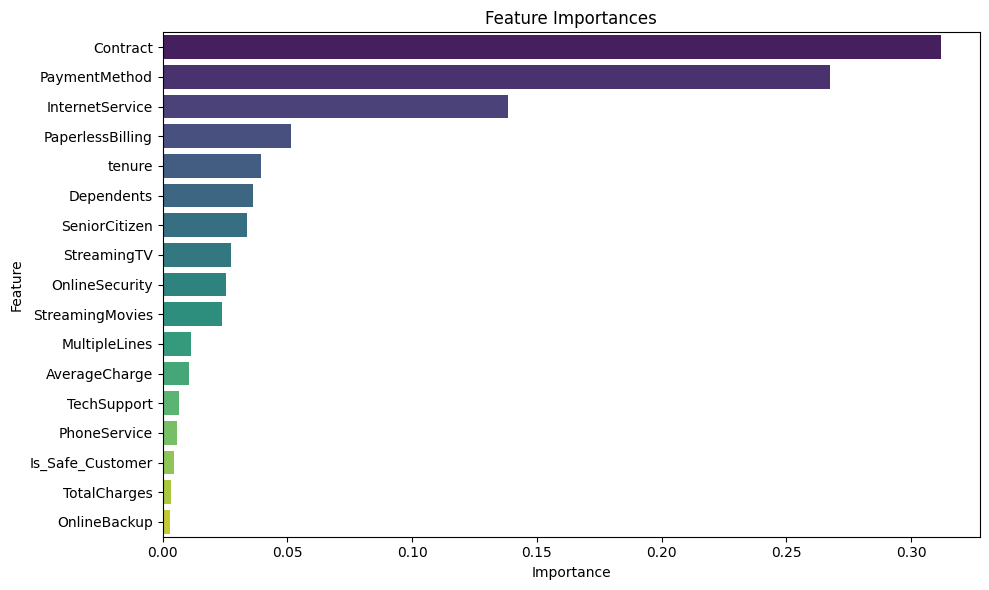

In [22]:
feature_names = [name.split('__')[-1] for name in pipeline.get_feature_names_out()]
avg_importance = np.mean([model.feature_importances_ for model in models], axis=0)

importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': avg_importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(25), x='Importance', y='Feature', hue='Feature', legend=False, palette='viridis')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

# Explainable AI (LIME)

In [23]:
!pip install lime

In [24]:
import lime
from lime.lime_tabular import LimeTabularExplainer

def ensemble_predict_proba(data_array):
    all_pred = [m.predict_proba(data_array) for m in models]

    return np.mean(all_pred, axis=0)

explainer = LimeTabularExplainer(
    training_data=X_tr,
    feature_names=feature_names,
    class_names=['Churn', 'No_churn'],
    mode='classification',
    random_state=42,
)

row_index=35

exp = explainer.explain_instance(
    data_row=X_val[row_index], 
    predict_fn=ensemble_predict_proba
)

exp.show_in_notebook(show_table=True)

# Submission

In [25]:
predictions = test_pred_xgb

raw_test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")
# test_pred_xgb = np.zeros(len(test_df))
# test_pred_lgb = np.zeros(len(test_df))
# test_pred_cat = np.zeros(len(test_df))
submission = pd.DataFrame({
    "id": raw_test["id"],
    "Churn": predictions

})
# submission_xgb = pd.DataFrame({
#     "id":raw_test["id"],
#     "Churn":test_pred_xgb
# })
# submission_lgbm = pd.DataFrame({
#     "id":raw_test["id"],
#     "Churn":test_pred_lgb
# })
# submission_cat = pd.DataFrame({
#     "id":raw_test["id"],
#     "Churn":test_pred_cat
# })


submission.to_csv("submission.csv", index=False)
# submission_xgb.to_csv("xgb.csv", index=False)
# submission_lgbm.to_csv("lgbm.csv", index=False)
# submission_cat.to_csv("cat.csv", index=False)